# **Proyecto ML - Parte 1:**
Jose Manuel Fonseca -202122456\
Julian Pinto - \
Daniel Vergara - 

## Contexto y objetivo

En este proyecto vamos a clasificar reseñas de productos en español como positivas, negativas o neutrales. Algunas reseñas mezclan cosas buenas y malas del producto, por lo que no siempre es fácil identificar la opinión general.

Tenemos 12.000 reseñas con etiqueta para entrenar y evaluar el modelo, y 3.000 sin etiqueta para generar las predicciones que enviaremos a Kaggle.

Para esta primera parte usaremos TF-IDF y modelos clásicos de scikit-learn. Empezaremos con un modelo sencillo y probaremos si tener en cuenta la parte final de las reseñas ayuda a mejorar los resultados.

La métrica principal será accuracy, que mide la proporción de reseñas clasificadas correctamente. También revisaremos los errores para entender en qué casos falla el modelo.

## Imports

In [47]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)
RANDOM_STATE = 42


## Carga de datos

Cargamos train.csv, que contiene texto y etiqueta, y eval.csv, que no tiene etiquetas. Este último se usará para generar el envío a Kaggle.


In [48]:
train = pd.read_csv("train.csv")
eval_df = pd.read_csv("eval.csv")

print("train:", train.shape)
print("eval:", eval_df.shape)
train.head()

train: (12000, 3)
eval: (3000, 2)


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


## Exploración de los datos

### Calidad y distribución de clases

Revisamos valores faltantes, duplicados y la cantidad de reseñas de cada etiqueta.


Valores nulos por columna


,train,eval
id,0,0.0
label,0,No aplica
text,0,0.0


Textos duplicados


,train,eval
Duplicados,0,0


Distribución de clases


,Cantidad,Porcentaje
Etiqueta,,
positivo,4212,35.1
negativo,4212,35.1
neutral,3576,29.8


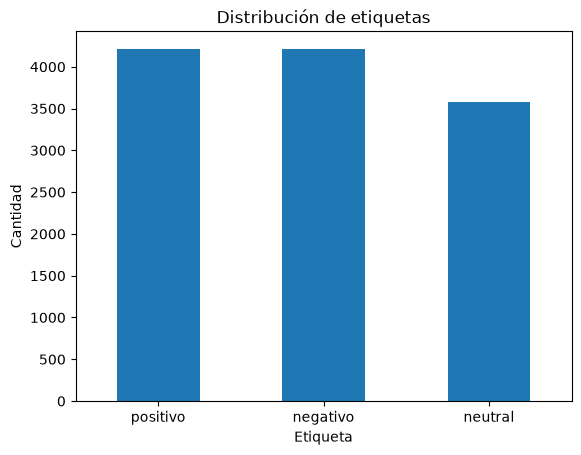

In [49]:
print("Valores nulos por columna")
display(pd.DataFrame({
    "train": train.isna().sum(),
    "eval": eval_df.isna().sum(),
}).fillna("No aplica"))

print("Textos duplicados")
display(pd.DataFrame({
    "train": [train["text"].duplicated().sum()],
    "eval": [eval_df["text"].duplicated().sum()],
}, index=["Duplicados"]))

conteos = train["label"].value_counts()

print("Distribución de clases")
display(pd.DataFrame({
    "Cantidad": conteos,
    "Porcentaje": (conteos / len(train) * 100).round(2),
}).rename_axis("Etiqueta"))

conteos.plot(
    kind="bar",
    title="Distribución de etiquetas",
    ylabel="Cantidad",
    xlabel="Etiqueta",
    rot=0,
)
plt.show()

Las clases están relativamente equilibradas: positivo y negativo tienen 4.212 reseñas cada una (35,1 %), y neutral tiene 3.576 (29,8 %). Empezaremos sin pesos especiales por clase y evaluaremos si cambiarlos mejora los resultados.

### Textos vacíos e identificadores


In [50]:
revision = pd.DataFrame({
    "train": [
        train["text"].str.strip().eq("").sum(),
        train["id"].isna().sum(),
        train["id"].duplicated().sum(),
    ],
    "eval": [
        eval_df["text"].str.strip().eq("").sum(),
        eval_df["id"].isna().sum(),
        eval_df["id"].duplicated().sum(),
    ],
}, index=[
    "Textos vacíos o con solo espacios",
    "Identificadores nulos",
    "Identificadores repetidos",
])

display(revision)

,train,eval
Textos vacíos o con solo espacios,0,0
Identificadores nulos,0,0
Identificadores repetidos,0,0


No encontramos valores faltantes, textos vacíos ni textos o identificadores repetidos dentro de cada archivo. No necesitamos eliminar filas ni completar valores.


### Ejemplos por clase

Leemos tres reseñas por clase para entender su contenido. Son ejemplos para proponer ideas, no conclusiones sobre todos los datos.


In [51]:
for etiqueta in ["positivo", "negativo", "neutral"]:
    print(f"\n--- {etiqueta.upper()} ---")

    ejemplos = train.loc[
        train["label"] == etiqueta, "text"
    ].sample(3, random_state=RANDOM_STATE)

    for numero, texto in enumerate(ejemplos, start=1):
        print(f"\n{numero}. {texto}")


--- POSITIVO ---

1. Me llegó el equipo a casa en tres días, lo pedí un martes por la noche y ya estaba probándolo el viernes. Después de usarlo bastante, lo pruebo casi todos los días, más que nada en las tardes después del trabajo. Para mí, el rendimiento me resultó ser mal terminado en el uso real. Lo tengo conectado en el escritorio del cuarto, con el cargador original de 65W. Sin embargo, el procesador se mantuvo espectacular en el uso real.

2. La compré hace un par de meses por internet y llegó en tres días a mi casa. Ya con un tiempo de uso, lo uso para el gimnasio, principalmente cuando voy en las tardes después del trabajo. La instalación la hizo mi cuñado un sábado en la mañana y no hubo ningún problema. Terminé feliz con la instalación.

3. Hace un par de semanas lo pedi porque lo necesitaba para el trabajo, me llego en unos tres dias a la oficina. Me alegra haber elegido la ergonomia. Lo uso todos los dias en el escritorio junto a la laptop. De paso, la app del fabricante

### Observaciones de las reseñas

En los ejemplos positivos y negativos encontramos reseñas que mezclan
elogios y críticas. Por eso, identificar palabras positivas o negativas
por separado puede no ser suficiente para clasificar la opinión general.

En algunos casos, la opinión final coincide con la etiqueta, pero también
hay ejemplos donde ocurre lo contrario. Probaremos si representar la
parte final junto con el texto completo ayuda al modelo.

Los ejemplos neutrales describen principalmente el envío, el uso y las
características del producto. También observamos textos sin tildes y
algunos errores de escritura.

### Longitud de las reseñas

Contamos las palabras separadas por espacios y comparamos las longitudes por clase.


In [52]:
longitudes = train.assign(
    palabras=train["text"].str.split().str.len()
)

display(
    longitudes.groupby("label")["palabras"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

,count,mean,median,min,max
label,,,,,
negativo,4212,54.23,54.0,6,100
neutral,3576,52.28,52.0,3,96
positivo,4212,55.00,55.0,5,110


Las reseñas de las tres clases tienen una longitud similar: el promedio
está entre 52 y 55 palabras y las medianas son cercanas. No observamos
una diferencia marcada de longitud entre las etiquetas.

## Decisiones a partir de la exploración

Conservaremos todas las filas, las tildes, las negaciones y los conectores. Usaremos solo el texto como entrada; el identificador no será una característica.

Empezaremos sin pesos especiales por clase porque las proporciones son cercanas. Primero evaluaremos el texto completo y después probaremos sus partes finales.


## Separación de entrenamiento y validación

Usaremos el 80 % de las reseñas para entrenar y comparar los modelos.
Reservaremos el 20 % restánte para evaluar el modelo elegido al final.

La separación mantendrá aproximadamente la proporción de cada clase.
Usaremos una semilla fija para poder repetirla.

In [53]:
X = train["text"]
y = train["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Entrenamiento:", len(X_train))
print("Validación:", len(X_valid))

Entrenamiento: 9600
Validación: 2400


## Representación con TF-IDF

TF-IDF convierte cada reseña en números y da más peso a términos frecuentes en ella, pero poco comunes en el conjunto. Aprendemos el vocabulario solo con entrenamiento, usando palabras individuales.


In [54]:
vectorizador = TfidfVectorizer()

X_train_tfidf = vectorizador.fit_transform(X_train)

print("Dimensiones:", X_train_tfidf.shape)
vectorizador.get_feature_names_out()[:20]

Dimensiones: (9600, 5504)


array(['10', '100', '10000', '110', '110v', '120', '120v', '127v', '128',
       '128gb', '14', '15', '16', '18w', '1tb', '200', '2000', '20000',
       '20w', '220'], dtype=object)

La representación tiene 9.600 filas y 5.504 términos. Los términos mostrados están ordenados alfabéticamente, no por importancia.


## Primer modelo: regresión logística

El clasificador aprende pesos para relacionar los términos con las tres etiquetas. Aunque se llama regresión, aquí se usa para clasificar. max_iter=1000 fija el límite de iteraciones del ajuste.


In [55]:
modelo = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)

modelo.fit(X_train_tfidf, y_train)
print("Modelo entrenado")

Modelo entrenado


## Validación cruzada

Usamos cinco particiones estratificadas del conjunto de entrenamiento. El Pipeline une TF-IDF y el clasificador para que cada partición aprenda su propio vocabulario sin usar las reseñas que evalúa. Las 2.400 reseñas finales siguen reservadas.

El entrenamiento anterior muestra los pasos por separado; aquí se vuelven a entrenar dentro de cada partición para medir su desempeño.


In [56]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("modelo", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

resultados = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
)

display(pd.DataFrame({
    "accuracy": resultados["test_score"]
}))

print("Accuracy promedio:", resultados["test_score"].mean())
print("Desviación estándar:", resultados["test_score"].std())

,accuracy
0,0.734896
1,0.724479
2,0.725521
3,0.740104
4,0.694271


Accuracy promedio: 0.7238541666666667
Desviación estándar: 0.0159017163643845


El modelo con TF-IDF y regresión logística obtuvo un accuracy promedio
de 72,39 % en validación cruzada. Los resultados variaron entre 69,43 %
y 74,01 %, con una desviación de 1,59 puntos porcentuales.

Este resultado será nuestra referencia para comparar las siguientes
configuraciones.

## Resultados por clase

Obtenemos una predicción para cada reseña con un modelo que no la vio durante el entrenamiento. Precision mide cuántas predicciones de una clase son correctas; recall, cuántos ejemplos reales de esa clase reconocemos; F1 combina ambas medidas. En la matriz, las filas son las etiquetas reales y las columnas las predicciones.


              precision    recall  f1-score   support

    negativo      0.623     0.604     0.613      3369
     neutral      0.956     0.995     0.975      2861
    positivo      0.616     0.614     0.615      3370

    accuracy                          0.724      9600
   macro avg      0.732     0.737     0.734      9600
weighted avg      0.720     0.724     0.722      9600



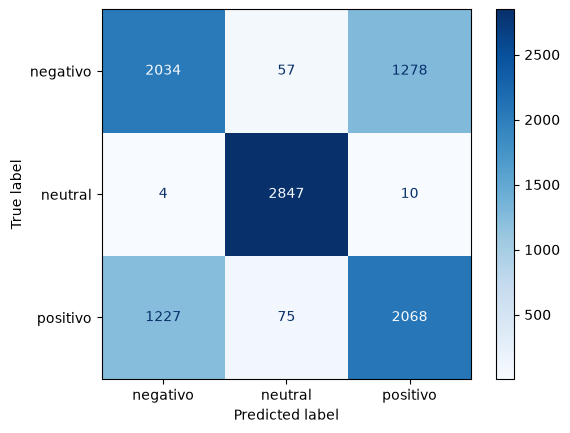

In [57]:
predicciones_cv = cross_val_predict(
    pipeline,
    X_train,
    y_train,
    cv=cv,
)

print(classification_report(
    y_train,
    predicciones_cv,
    digits=3,
))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    predicciones_cv,
    labels=["negativo", "neutral", "positivo"],
    cmap="Blues",
)
plt.show()

El modelo reconoce el 99,5 % de las reseñas neutrales, pero solo el 60,4 % de las negativas y el 61,4 % de las positivas. Las siguientes pruebas buscarán mejorar la distinción de estas clases.


## Registro de experimentos

Registraremos el cambio de cada intento y su resultado. El score de Kaggle se añadirá cuando hagamos el envío; la validación local no lo reemplaza.

| Experimento | Configuración | Accuracy CV | Desviación | Score público Kaggle | Conclusión |
|---|---|---|---|---|---|
| 1 | TF-IDF de palabras individuales + regresión logística | 72,39 % | 1,59 puntos | Pendiente | Neutral se reconoce bien; positivo y negativo necesitan mejorar. |

La línea base oficial de la competencia queda pendiente de confirmar.


In [58]:
from sklearn.base import clone

modelo_envio = clone(pipeline)
modelo_envio.fit(train["text"], train["label"])

predicciones_eval = modelo_envio.predict(eval_df["text"])

submission = pd.DataFrame({
    "id": eval_df["id"],
    "answer": predicciones_eval,
})

plantilla = pd.read_csv("sample_submission.csv")

assert list(submission.columns) == list(plantilla.columns)
assert submission["id"].tolist() == plantilla["id"].tolist()
assert submission["id"].is_unique
assert not submission.isna().any().any()
assert submission["answer"].isin(
    ["positivo", "negativo", "neutral"]
).all()

carpeta_envios = Path("submissions")
carpeta_envios.mkdir(exist_ok=True)

ruta_envio = carpeta_envios / "submission_01_tfidf_logreg.csv"
submission.to_csv(ruta_envio, index=False)

display(submission.head())
print("Archivo guardado en:", ruta_envio.resolve())

,id,answer
0,0,neutral
1,1,negativo
2,2,neutral
3,3,neutral
4,4,neutral


Archivo guardado en: /Users/josefonseca/Desktop/Andes/Onceavo Semestre/Machine Learning/ISIS-2611-Proyecto-Parte-1/submissions/submission_01_tfidf_logreg.csv
